<a href="https://colab.research.google.com/github/Santiago154/Gestion-y-configuracion/blob/main/Transfer_Learning_Lectura_enfermedades_plantas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección de Enfermedades en Hojas

## Proyecto Final — Aprendizaje de Máquinas

**Dataset:** PlantVillage  
**Técnica utilizada:** Transfer Learning  
**Arquitectura empleada:** EfficientNetB0  

---

### Integrantes

- Joseph Santiago Jiemenz  
- Santiago Restrepo Silva

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Clasificación de Enfermedades en Hojas mediante Transfer Learning
### EfficientNetB0 aplicado al dataset PlantVillage

---

## 1. Introducción

La agricultura moderna enfrenta uno de sus mayores desafíos en la detección oportuna de enfermedades en cultivos. Las pérdidas generadas por patologías vegetales no detectadas a tiempo representan una amenaza directa sobre la seguridad alimentaria y la rentabilidad de los productores. Tradicionalmente, este diagnóstico ha dependido de la inspección visual manual por parte de expertos agrónomos, un proceso costoso, lento y difícilmente escalable.

El avance en visión por computadora y aprendizaje profundo ha abierto una alternativa viable: la clasificación automática de imágenes de hojas para identificar patologías con alta precisión y en tiempo real.

En este proyecto se implementa un modelo de clasificación de imágenes utilizando **Transfer Learning** sobre la arquitectura **EfficientNetB0**, preentrenada sobre ImageNet, aplicada al dataset **PlantVillage**. El objetivo principal consiste en evaluar la capacidad de una red neuronal convolucional preentrenada para reconocer patrones visuales asociados a enfermedades vegetales y clasificar correctamente cada imagen según su categoría.

> **Nota sobre limitaciones computacionales:** El dataset PlantVillage en su versión completa alberga alrededor de 1500 imagenes por cada clase (siendo un total de más de 10 clases). Sin embargo, debido a las restricciones de memoria RAM y tiempo de cómputo impuestas por el entorno **Google Colab en su modalidad gratuita** — que ofrece acceso limitado y no exclusivo a GPU —, no fue posible entrenar el modelo sobre la totalidad del dataset. Por esta razón, se trabajó con un subconjunto representativo de entre **250 y 300 imágenes por clase** y reduciendo el número de clases a 9, lo que permitió completar el entrenamiento en un tiempo razonable sin comprometer la validez del experimento.

# 2. Importación de Librerías

En esta sección se importan las librerías necesarias para el desarrollo del proyecto de clasificación de enfermedades en hojas mediante técnicas de Deep Learning y Transfer Learning.

Las principales librerías utilizadas son:

- **TensorFlow y Keras:** utilizadas para la construcción, entrenamiento y evaluación de la red neuronal convolucional.
- **EfficientNetB0:** arquitectura preentrenada empleada como modelo base para aplicar Transfer Learning.
- **NumPy y Pandas:** utilizadas para manipulación y procesamiento de datos.
- **Matplotlib:** empleada para la visualización de métricas y gráficas de entrenamiento.
- **Scikit-learn:** utilizada para generar métricas de evaluación como matriz de confusión y reporte de clasificación.
- **Torch y Torchvision:** utilizadas como librerías complementarias para procesamiento y manejo de imágenes.
- **Google Colab Files:** utilizada para exportar y descargar resultados generados durante la ejecución del proyecto.

In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms, models

from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
import tensorflow as tf

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

In [ ]:
dataset_path = "/content/drive/MyDrive/Proyecto Final - Machine Learning/PlantVillage"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

class_names = train_ds.class_names
print(class_names)
print("Cantidad de clases:", len(class_names))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2004 files belonging to 9 classes.
Using 1604 files for training.
Found 2004 files belonging to 9 classes.
Using 400 files for validation.
['Pepper_Bell_Bacterial_Spot', 'Pepper_Bell_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Late_Blight', 'Tomato_Septoria_Leaf_Spot', 'Tomato__Healthy']
Cantidad de clases: 9


In [ ]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [ ]:
num_classes = len(class_names)

base_model = EfficientNetB0(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs  = layers.Input(shape=(256, 256, 3))
x       = data_augmentation(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

modelo = models.Model(inputs, outputs)

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,820 (16.71 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

historial = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.6340 - loss: 1.0152 - val_accuracy: 0.8600 - val_loss: 0.4693 - learning_rate: 0.0010
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 210s 4s/step - accuracy: 0.8423 - loss: 0.4605 - val_accuracy: 0.8925 - val_loss: 0.3480 - learning_rate: 0.0010
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 212s 4s/step - accuracy: 0.8965 - loss: 0.3335 - val_accuracy: 0.9000 - val_loss: 0.2876 - learning_rate: 0.0010
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - accuracy: 0.8965 - loss: 0.2955 - val_accuracy: 0.9175 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 214s 4s/step - accuracy: 0.9140 - loss: 0.2565 - val_accuracy: 0.9025 - val_loss: 0.2805 - learning_rate: 0.0010
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 214s 4s/step - accuracy: 0.9289 - loss: 0.2310 - val_accuracy: 0.9075 - val_loss: 0.2541 - learning_rate: 0.0010
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 214s 4s/step - accuracy: 0.9383 - loss: 0.1901 - val_acc

In [ ]:
# =========================================================
# Ruta donde se guardarán los resultados del proyecto
# =========================================================

# ruta_guardado = "/content/drive/MyDrive/Proyecto Final - Machine Learning/resultados modelo transfer learning"

# os.makedirs(ruta_guardado, exist_ok=True)

# =========================================================
# Guardar historial del entrenamiento
# =========================================================

# Convierte el historial del entrenamiento en un DataFrame
# historial_df = pd.DataFrame(historial.history)

# Guarda el historial en formato CSV
# historial_df.to_csv(
#     os.path.join(ruta_guardado, "historial_entrenamiento.csv"),
#     index=False
# )

# Guarda el historial en formato Excel
# historial_df.to_excel(
#     os.path.join(ruta_guardado, "historial_entrenamiento.xlsx"),
#     index=False
# )

# =========================================================
# Guardar modelo entrenado
# =========================================================

# Guarda el modelo completo entrenado
# modelo.save(
#     os.path.join(ruta_guardado, "modelo_efficientnet_plantvillage.keras")
# )

# Mensaje de confirmación
# print("Todo guardado correctamente.")

Todo guardado correctamente.


In [ ]:
ruta_guardado = "/content/drive/MyDrive/Proyecto Final - Machine Learning/resultados modelo transfer learning"

historial_df = pd.read_csv(
    os.path.join(ruta_guardado, "historial_entrenamiento.csv")
)

modelo = tf.keras.models.load_model(
    os.path.join(ruta_guardado, "modelo_efficientnet_plantvillage.keras")
)

print("Modelo e historial cargados.")

Modelo e historial cargados.


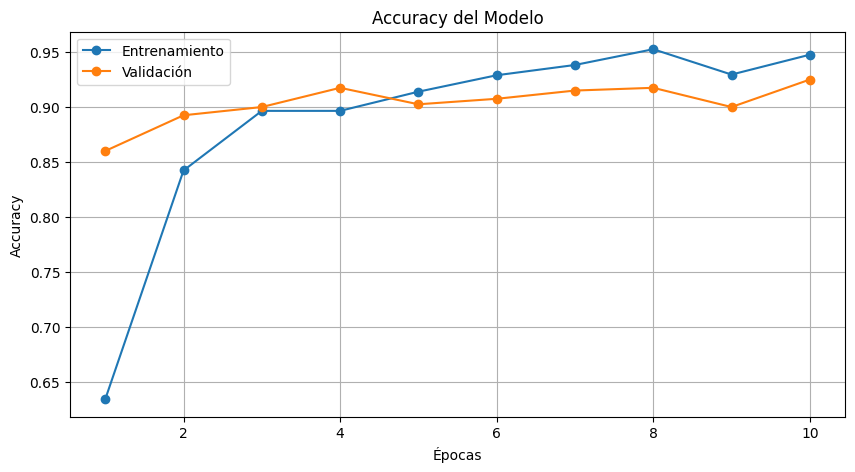

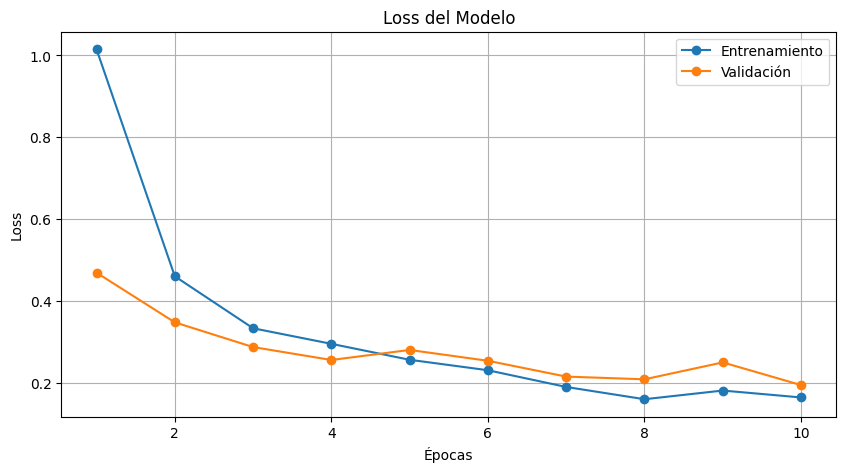

In [ ]:
# =========================
# GRÁFICAS DEL ENTRENAMIENTO
# =========================

import matplotlib.pyplot as plt

acc      = historial_df['accuracy']
val_acc  = historial_df['val_accuracy']

loss     = historial_df['loss']
val_loss = historial_df['val_loss']

epochs = range(1, len(acc) + 1)

# -------------------------
# Accuracy
# -------------------------

plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    acc,
    marker='o',
    label='Entrenamiento'
)

plt.plot(
    epochs,
    val_acc,
    marker='o',
    label='Validación'
)

plt.title("Accuracy del Modelo")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.grid(True)

plt.show()

# -------------------------
# Loss
# -------------------------

plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    loss,
    marker='o',
    label='Entrenamiento'
)

plt.plot(
    epochs,
    val_loss,
    marker='o',
    label='Validación'
)

plt.title("Loss del Modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


<Figure size 1200x1200 with 0 Axes>

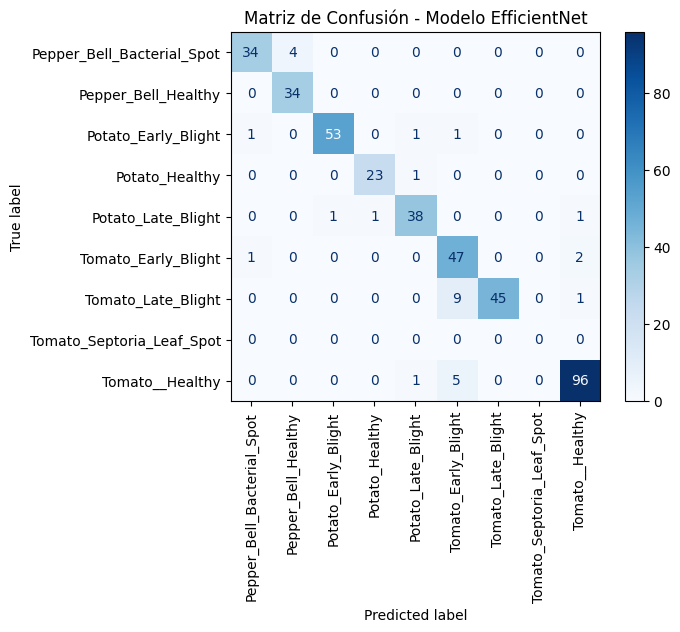

In [ ]:
# Lista para guardar etiquetas reales
y_true = []

# Lista para guardar predicciones del modelo
y_pred = []

# Recorre el dataset de validación
for imagenes, etiquetas in val_ds:

    # Predicciones del modelo
    predicciones = modelo.predict(imagenes)

    # Obtiene la clase con mayor probabilidad
    clases_predichas = np.argmax(predicciones, axis=1)

    # Guarda etiquetas reales
    y_true.extend(etiquetas.numpy())

    # Guarda etiquetas predichas
    y_pred.extend(clases_predichas)

# =========================================================
# Crear matriz de confusión
# =========================================================

matriz = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

# Tamaño de la figura
plt.figure(figsize=(12, 12))

# Mostrar matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format='d'
)

# Título del gráfico
plt.title("Matriz de Confusión - Modelo EfficientNet")

# Mostrar gráfico
plt.show()

Saving 6de912b6-f7e5-4980-be35-63ba2564d5d3___JR_HL 8059.JPG to 6de912b6-f7e5-4980-be35-63ba2564d5d3___JR_HL 8059.JPG


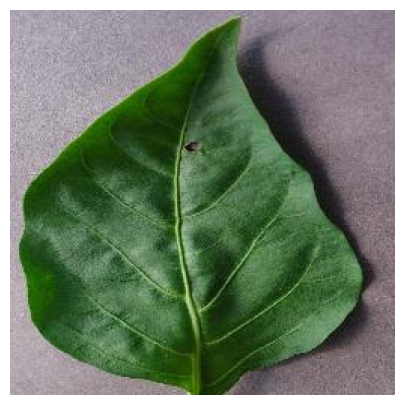

Resultados más probables:

Pepper_Bell_Healthy: 98.37%
Pepper_Bell_Bacterial_Spot: 1.61%
Potato_Healthy: 0.01%
Potato_Late_Blight: 0.01%
Tomato_Early_Blight: 0.00%

Diagnóstico final: Pepper_Bell_Healthy
Confianza: 98.4%


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files

def predecir_imagen(ruta_imagen, top_k=5):
    img = tf.keras.utils.load_img(
        ruta_imagen,
        target_size=(256, 256),
        color_mode="rgb"
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predicciones = modelo.predict(img_array, verbose=0)[0]

    indices_top = np.argsort(predicciones)[::-1][:top_k]

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Resultados más probables:\n")

    for i in indices_top:
        print(f"{class_names[i]}: {predicciones[i] * 100:.2f}%")

    indice_clase = indices_top[0]
    clase_predicha = class_names[indice_clase]
    confianza = predicciones[indice_clase] * 100

    return clase_predicha, confianza


subida = files.upload()
ruta = list(subida.keys())[0]

clase, confianza = predecir_imagen(f"/content/{ruta}")

print("\nDiagnóstico final:", clase)
print(f"Confianza: {confianza:.1f}%")

#Segundo modelo de implementación

In [ ]:
# ==========================================
# 2. IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input  # ← Importante
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from google.colab import drive

In [ ]:
dataset_path = "/content/drive/MyDrive/Proyecto Final - Machine Learning/PlantVillage"

In [ ]:
# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
# Parámetros fijos (no cambiar)
IMG_SIZE = (224, 224)   # Tamaño usado en el entrenamiento exitoso
BATCH_SIZE = 32         # Mismo batch size que en el log
NUM_CLASSES = 9
EPOCHS = 25


In [ ]:
# ==========================================
# 4. CARGAR RUTAS DE IMÁGENES Y DIVIDIR (estratificado)
# ==========================================
def load_dataset_paths(directory):
    paths = []
    labels = []
    class_names = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                paths.append(os.path.join(class_dir, fname))
                labels.append(class_to_idx[class_name])
    return paths, labels, class_names

print("Cargando rutas de imágenes...")
file_paths, labels, class_names = load_dataset_paths(dataset_path)
print(f"Total imágenes: {len(file_paths)}. Clases: {class_names}")

# División estratificada 70% train, 15% val, 15% test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    file_paths, labels, test_size=0.3, stratify=labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Cargando rutas de imágenes...
Total imágenes: 2004. Clases: ['Pepper_Bell_Bacterial_Spot', 'Pepper_Bell_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Late_Blight', 'Tomato_Septoria_Leaf_Spot', 'Tomato__Healthy']
Train: 1402 | Val: 301 | Test: 301


In [ ]:
# ==========================================
# 5. CREAR DATASETS tf.data (con aumento de datos Y preprocesamiento de EfficientNet)
# ==========================================
def decode_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # Convertir a float32 y aplicar el preprocesamiento de EfficientNet (NO dividir por 255)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)   # ← Esta es la corrección clave
    if augment:
        # Aumento de datos ligero (igual al que funcionó)
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        # Rotación aleatoria pequeña
        angle = tf.random.uniform([], -0.2, 0.2)
        img = tf.image.rot90(img, k=tf.cast(angle * 10, tf.int32) % 4)
    return img, tf.one_hot(label, NUM_CLASSES)

# Dataset de entrenamiento (con aumento)
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(lambda x, y: decode_image(x, y, augment=True),
                        num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Dataset de validación (sin aumento)
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(lambda x, y: decode_image(x, y, augment=False),
                    num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Dataset de prueba (sin aumento)
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(lambda x, y: decode_image(x, y, augment=False),
                      num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# ==========================================
# 6. CONSTRUIR MODELO CON EfficientNetB0 (base congelada)
# ==========================================
# Cargar EfficientNetB0 preentrenada en ImageNet, sin la cabeza superior
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # Congelar toda la base (sin fine‑tuning)

# Construir la cabeza personalizada
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)  # training=False porque la base está congelada
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# Compilar (learning rate igual al que funcionó: 1e-4)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n=== Resumen del modelo ===")
model.summary()



=== Resumen del modelo ===


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,700 (16.08 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ==========================================
# 7. CALCULAR PESOS DE CLASE PARA BALANCEAR
# ==========================================
# Obtener etiquetas únicas presentes en train
unique_train_labels = np.unique(train_labels)
# Calcular pesos balanceados solo para las clases presentes
weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_train_labels,
    y=train_labels
)
# Crear diccionario con los pesos
class_weight_dict = dict(zip(unique_train_labels, weights_array))
# Asegurar que todas las clases (0 a NUM_CLASSES-1) tengan un peso (las ausentes con peso 0)
for i in range(NUM_CLASSES):
    if i not in class_weight_dict:
        class_weight_dict[i] = 0.0
# Ordenar para claridad
class_weight_dict = {k: class_weight_dict[k] for k in sorted(class_weight_dict.keys())}
print("Pesos de clase calculados:", class_weight_dict)

Pesos de clase calculados: {np.int64(0): np.float64(1.269927536231884), np.int64(1): np.float64(1.2517857142857143), np.int64(2): np.float64(1.2517857142857143), np.int64(3): np.float64(1.653301886792453), np.int64(4): np.float64(1.2517857142857143), np.int64(5): np.float64(1.0014285714285713), np.int64(6): np.float64(1.0014285714285713), 7: 0.0, np.int64(8): np.float64(0.45167525773195877)}


In [ ]:
# ==========================================
# 8. DEFINIR CALLBACKS
# ==========================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)
checkpoint = ModelCheckpoint(
    '/tmp/best_efficientnet.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
# 9. ENTRENAMIENTO (una sola etapa, sin fine‑tuning)
# ==========================================
print("\n=== ENTRENANDO MODELO (base congelada) ===")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Cargar los mejores pesos guardados durante el entrenamiento
model.load_weights('/tmp/best_efficientnet.h5')
print("\nMejor modelo cargado desde checkpoint.")


In [ ]:
# ==========================================
# 10. EVALUACIÓN EN EL CONJUNTO DE TEST
# ==========================================
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n Precisión en TEST: {test_acc:.4f}")
print(f"Pérdida en TEST: {test_loss:.4f}")

# Predicciones detalladas
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Get the unique labels that are actually present in the test set
unique_test_labels = np.unique(y_true)

# Filter class_names to match the unique labels present in the test set
# This ensures the target_names list has the same length and order as the unique_test_labels
filtered_class_names = [class_names[i] for i in unique_test_labels]

print("\n=== Reporte de clasificación por clase ===")
print(classification_report(y_true, y_pred, labels=unique_test_labels, target_names=filtered_class_names))

# Matriz de confusión
# Ensure confusion_matrix also uses the correct labels for indexing
cm = confusion_matrix(y_true, y_pred, labels=unique_test_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=filtered_class_names, yticklabels=filtered_class_names)
plt.title('Matriz de Confusión - Conjunto de Test')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=45)
plt.show()

NameError: name 'model' is not defined

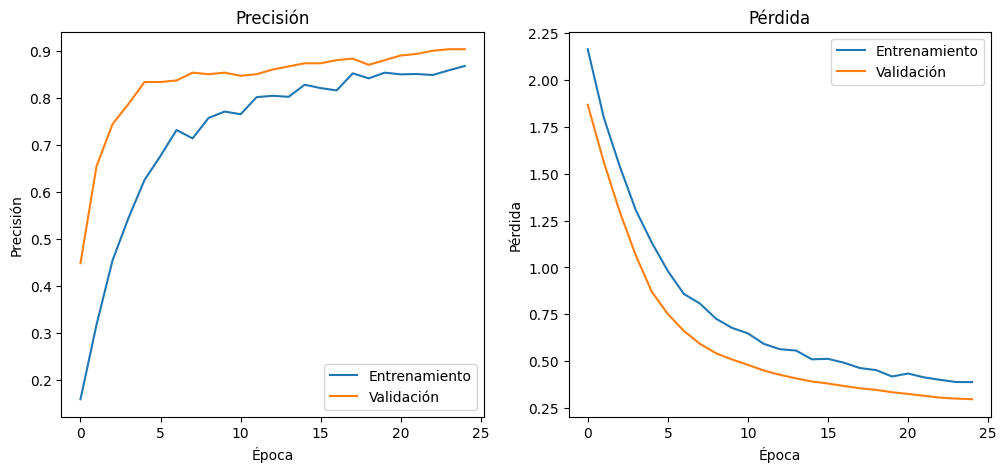

In [ ]:
# ==========================================
# 11. CURVAS DE APRENDIZAJE
# ==========================================
acc = historial_df['accuracy']
val_acc = historial_df['val_accuracy']
loss = historial_df['loss']
val_loss = historial_df['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento')
plt.plot(epochs_range, val_acc, label='Validación')
plt.legend(loc='lower right')
plt.title('Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento')
plt.plot(epochs_range, val_loss, label='Validación')
plt.legend(loc='upper right')
plt.title('Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.show()

In [ ]:
# ==========================================
# 12. GUARDAR HISTORIAL Y MODELO ENTRENADO
# ==========================================
import pandas as pd

ruta_guardado = "/content/drive/MyDrive/Proyecto Final - Machine Learning/ML data"
os.makedirs(ruta_guardado, exist_ok=True)

# Guardar historial como DataFrame
historial_df = pd.DataFrame(history.history)

# Guardar en CSV
historial_df.to_csv(
    os.path.join(ruta_guardado, "historial_entrenamiento.csv"),
    index=False
)

# Guardar en Excel
historial_df.to_excel(
    os.path.join(ruta_guardado, "historial_entrenamiento.xlsx"),
    index=False
)

# Guardar modelo completo entrenado
model.save(
    os.path.join(ruta_guardado, "modelo_efficientnet_plantvillage.keras")
)

print(" Historial y modelo guardados correctamente en:", ruta_guardado)

In [ ]:
# ==========================================
# 13. CARGAR HISTORIAL Y MODELO ENTRENADO
# ==========================================
import pandas as pd

ruta_guardado = "/content/drive/MyDrive/Proyecto Final - Machine Learning/ML data"

# Cargar historial
historial_df = pd.read_csv(
    os.path.join(ruta_guardado, "historial_entrenamiento.csv")
)

# Cargar modelo completo
model = tf.keras.models.load_model(
    os.path.join(ruta_guardado, "modelo_efficientnet_plantvillage.keras")
)

print(" Modelo e historial cargados correctamente desde:", ruta_guardado)
print(f"   Épocas registradas: {len(historial_df)}")
print(f"   Columnas del historial: {list(historial_df.columns)}")

NameError: name 'os' is not defined

Selecciona una imagen para predecir:


Saving fd75c626-bda9-4388-8b29-75d40ea7c6d4___RS_HL 0041.JPG to fd75c626-bda9-4388-8b29-75d40ea7c6d4___RS_HL 0041.JPG


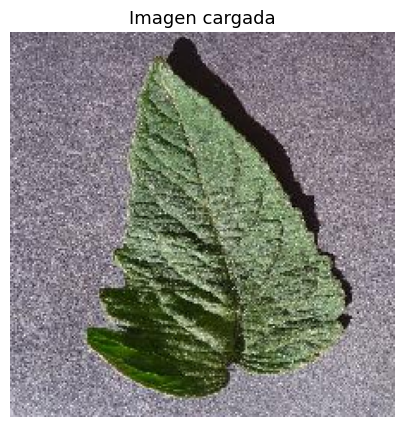

📐 PARÁMETROS DE PROCESAMIENTO
  Tamaño de entrada        : (224, 224)
  Canales                  : RGB (3)
  Preprocesamiento         : EfficientNet (preprocess_input)
  Normalización            : Escala [-1, 1] (interna de EfficientNet)
  Shape enviado al modelo  : (1, 224, 224, 3)
  Número de clases         : 9

🔍 TOP 5 PREDICCIONES
  1. Tomato__Healthy                                92.24%  ███████████████████████████
  2. Tomato_Early_Blight                             4.13%  █
  3. Potato_Healthy                                  1.76%  
  4. Potato_Late_Blight                              0.89%  
  5. Tomato_Late_Blight                              0.77%  

 DIAGNÓSTICO FINAL
  Clase predicha : Tomato__Healthy
  Confianza      : 92.24%


In [ ]:
# ==========================================
# 14. PREDICCIÓN SOBRE IMAGEN CARGADA
# ==========================================
from google.colab import files
from tensorflow.keras.applications.efficientnet import preprocess_input

def predecir_imagen(ruta_imagen, top_k=5):
    # Cargar y preprocesar con los mismos parámetros del entrenamiento
    img = tf.keras.utils.load_img(
        ruta_imagen,
        target_size=IMG_SIZE,
        color_mode="rgb"
    )

    img_array = tf.keras.utils.img_to_array(img)        # (224, 224, 3)
    img_array = tf.cast(img_array, tf.float32)
    img_array = preprocess_input(img_array)              # Mismo preprocesamiento que en entrenamiento
    img_array = np.expand_dims(img_array, axis=0)        # (1, 224, 224, 3)

    predicciones = model.predict(img_array, verbose=0)[0]  # Array de NUM_CLASSES probabilidades

    indices_top = np.argsort(predicciones)[::-1][:top_k]

    # Mostrar imagen
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Imagen cargada", fontsize=13)
    plt.show()

    # Parámetros de procesamiento
    print("=" * 50)
    print("📐 PARÁMETROS DE PROCESAMIENTO")
    print("=" * 50)
    print(f"  Tamaño de entrada        : {IMG_SIZE}")
    print(f"  Canales                  : RGB (3)")
    print(f"  Preprocesamiento         : EfficientNet (preprocess_input)")
    print(f"  Normalización            : Escala [-1, 1] (interna de EfficientNet)")
    print(f"  Shape enviado al modelo  : {img_array.shape}")
    print(f"  Número de clases         : {NUM_CLASSES}")
    print()

    # Resultados
    print("=" * 50)
    print(f"🔍 TOP {top_k} PREDICCIONES")
    print("=" * 50)
    for rank, i in enumerate(indices_top, start=1):
        barra = "█" * int(predicciones[i] * 30)
        print(f"  {rank}. {class_names[i]:<45} {predicciones[i] * 100:6.2f}%  {barra}")
    print()

    # Resultado final
    indice_clase = indices_top[0]
    clase_predicha = class_names[indice_clase]
    confianza = predicciones[indice_clase] * 100

    print("=" * 50)
    print(" DIAGNÓSTICO FINAL")
    print("=" * 50)
    print(f"  Clase predicha : {clase_predicha}")
    print(f"  Confianza      : {confianza:.2f}%")

    # Advertencia si la confianza es baja
    if confianza < 60:
        print(f"\n  Confianza baja — el modelo no está seguro de esta predicción.")

    return clase_predicha, confianza


# Subir imagen y predecir
print("Selecciona una imagen para predecir:")
subida = files.upload()
ruta = list(subida.keys())[0]

clase, confianza = predecir_imagen(f"/content/{ruta}")